# 24 — Regional rock-abundance map (circum-Chryse)

Documentation + analysis for [PLAN_RegionalMap.md](../PLAN_RegionalMap.md): the first
real **regional deployment** of the frozen head + Stage-1 `CalibrationLayer`, tested
against the boulder-rich Late-Hesperian tsunami deposits of
[Rodriguez et al. 2016, *Sci. Rep.* 6:25106](https://doi.org/10.1038/srep25106) and
independent **THEMIS / TES thermal inertia**.

**This notebook, §1:** *what region are we mapping?* It draws the **26-tile circum-Chryse
regional map** that `scripts/map_region.py --all` runs on Sherlock (the box
`lon[-10,10] lat[32,46]` snapped to whole 4° Murray tiles, plus the 2 original NE tiles
`E12_N44`, `E16_N44`) over the circum-Chryse / NW Arabia Terra highland-lowland boundary —
with the cohort HiRISE footprints that train/anchor the model overlaid. The key realisation
(PLAN §0): boulder-rich cohort images sit **on this boundary**, and the paper's Fig-2C image
**ESP_017355_2260** *is* a cohort image, so the region is in-distribution where we lead and
OOD in the distal plains / southern highlands where we stress-test. §1a records how the box
was chosen (the first run mapped only the 7 eastern tiles; the map was then widened).

Later sections: the calibrated abundance mosaic (§2), then the 5 validation legs (§3) —
abundance↔thermal-inertia correlation, the shoreline-distance profile, the cohort
truth-anchor, and the OOD-honesty panel.


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
FIG = REPO / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

# The 26-tile circum-Chryse regional map (must match scripts/map_region.BLOCK_TILES):
# box lon[-10,10] lat[32,46] snapped to whole tiles (24) + the 2 original NE tiles.
BLOCK_TILES = [
    "E-12_N32", "E-12_N36", "E-12_N40", "E-12_N44", "E-8_N32", "E-8_N36", "E-8_N40", "E-8_N44",
    "E-4_N32", "E-4_N36", "E-4_N40", "E-4_N44", "E0_N32", "E0_N36", "E0_N40", "E0_N44",
    "E4_N32", "E4_N36", "E4_N40", "E4_N44", "E8_N32", "E8_N36", "E8_N40", "E8_N44",
    "E12_N44", "E16_N44",
]
TILE_DEG = 4  # Murray Lab tiles are 4 deg x 4 deg

def tile_to_box(name):
    """Murray tile id 'E16_N44' / 'W008_N32' -> (lon0, lat0) lower-left corner in deg."""
    e, n = name.split("_")
    lon = int(e[1:]) * (1 if e[0] == "E" else -1)
    lat = int(n[1:]) * (1 if n[0] == "N" else -1)
    return lon, lat

boxes = {t: tile_to_box(t) for t in BLOCK_TILES}
lons = [lo for lo, _ in boxes.values()]; lats = [la for _, la in boxes.values()]
block_extent = (min(lons), max(lons) + TILE_DEG, min(lats), max(lats) + TILE_DEG)
print("map tiles (%d):" % len(BLOCK_TILES), " ".join(BLOCK_TILES))
print("map extent  lon[%g, %g]  lat[%g, %g] deg" % block_extent)
print("map area ~ %d tiles x (4 deg)^2; full-res S=32 ~ %.0fM tiles"
      % (len(BLOCK_TILES), len(BLOCK_TILES) * 2.2))

map tiles (26): E-12_N32 E-12_N36 E-12_N40 E-12_N44 E-8_N32 E-8_N36 E-8_N40 E-8_N44 E-4_N32 E-4_N36 E-4_N40 E-4_N44 E0_N32 E0_N36 E0_N40 E0_N44 E4_N32 E4_N36 E4_N40 E4_N44 E8_N32 E8_N36 E8_N40 E8_N44 E12_N44 E16_N44
map extent  lon[-12, 20]  lat[32, 48] deg
map area ~ 26 tiles x (4 deg)^2; full-res S=32 ~ 57M tiles


In [2]:
# Cohort HiRISE footprints (centres) + rich/poor label.
cohort = pd.read_csv(REPO / "hirise_40_vclaire.csv")
cohort = cohort[["ObsId", "BoulderLabel", "CenterLat", "CenterLon_180"]].copy()
COL = {"Boulder rich": "#d62728", "Boulder poor": "#1f77b4", "unknown": "0.55"}
cohort["color"] = cohort.BoulderLabel.map(COL).fillna("0.55")

lo0, lo1, la0, la1 = block_extent
in_block = cohort[(cohort.CenterLon_180.between(lo0, lo1)) & (cohort.CenterLat.between(la0, la1))]
print("cohort total:", len(cohort))
print("cohort within the 26-tile map:", len(in_block))
print(in_block.BoulderLabel.value_counts().to_string())
PAPER_IMG = "ESP_017355_2260"  # Rodriguez+2016 Fig 2C; in our cohort

# Real HiRISE footprint boxes (the cached Stage-2 CTX-window bounds = footprint bbox + 1km buffer,
# in the pipeline target_crs). That CRS and the Murray map CRS are both equirectangular on
# R=3396190, so the same metres->degrees factor (dpm below) places them on the map. Used to CHECK
# that abundance structure does NOT coincide with HiRISE coverage (inference is pure CTX -- HiRISE
# never enters it -- so any coincidence would be a red flag).
import json as _json
_RDEG = 180.0 / (np.pi * 3396190.0)   # clon_0 / IAU-eqc metres -> degrees
footprints = {}   # ObsId -> (lon0, lat0, lon1, lat1) in degrees
for _, r in cohort.iterrows():
    j = REPO / "cache_v2" / "ctx_windows" / f"{r.ObsId}.json"
    if j.exists():
        b = _json.loads(j.read_text()).get("actual_bounds_target_crs")
        if b:
            footprints[r.ObsId] = (b[0] * _RDEG, b[1] * _RDEG, b[2] * _RDEG, b[3] * _RDEG)
print("HiRISE footprint boxes loaded:", len(footprints))
print("paper Fig-2C image in cohort:", PAPER_IMG in set(cohort.ObsId))

cohort total: 39
cohort within the 26-tile map: 23
BoulderLabel
Boulder rich    22
unknown          1
HiRISE footprint boxes loaded: 39
paper Fig-2C image in cohort: True


wrote reports\figures\24_region_extent.png


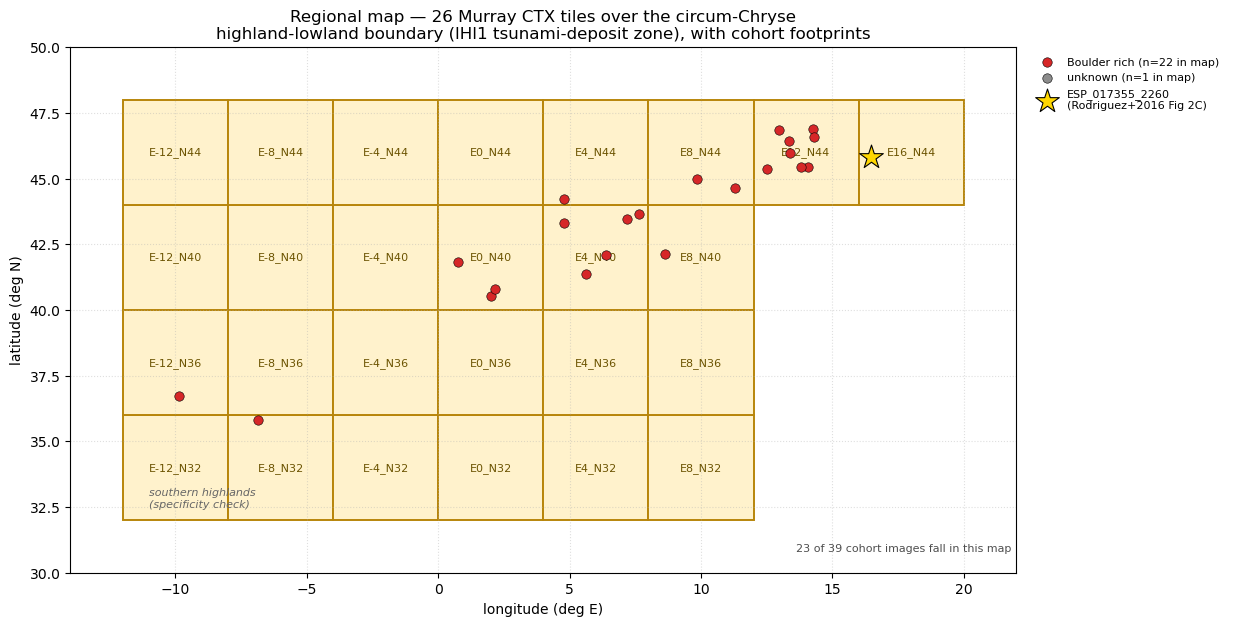

In [3]:
fig, ax = plt.subplots(figsize=(12, 6.4))

# 1) the 26 Murray tiles = the regional map.
for t, (lo, la) in boxes.items():
    ax.add_patch(Rectangle((lo, la), TILE_DEG, TILE_DEG, facecolor="#fff2cc",
                           edgecolor="#b8860b", lw=1.4, zorder=1))
    ax.text(lo + TILE_DEG / 2, la + TILE_DEG / 2, t, ha="center", va="center",
            fontsize=8, color="#6b5300", zorder=2)

# 2) cohort footprints WITHIN the map, coloured by label (count only what's drawn).
for lab, c in COL.items():
    sub = in_block[in_block.BoulderLabel == lab]
    if len(sub):
        ax.scatter(sub.CenterLon_180, sub.CenterLat, s=46, c=c, edgecolor="k",
                   lw=0.4, label=f"{lab} (n={len(sub)} in map)", zorder=4)

# 3) the paper's Fig-2C image — the parity / truth-anchor site.
pi = cohort[cohort.ObsId == PAPER_IMG]
if len(pi):
    ax.scatter(pi.CenterLon_180, pi.CenterLat, s=320, marker="*",
               facecolor="gold", edgecolor="k", lw=0.8, zorder=5,
               label=f"{PAPER_IMG}\n(Rodriguez+2016 Fig 2C)")

ax.set_xlim(lo0 - 2, lo1 + 2); ax.set_ylim(la0 - 2, la1 + 2)
ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
ax.set_title("Regional map — 26 Murray CTX tiles over the circum-Chryse\n"
             "highland-lowland boundary (lHl1 tsunami-deposit zone), with cohort footprints")
ax.grid(True, ls=":", alpha=0.4); ax.set_aspect("equal")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
ax.annotate("southern highlands\n(specificity check)", (lo0 + 1.0, la0 + 0.5),
            fontsize=8, style="italic", color="0.4")
ax.annotate(f"{len(in_block)} of {len(cohort)} cohort images fall in this map",
            (lo1 + 1.8, la0 - 1.2), ha="right", fontsize=8, color="0.3")
fig.tight_layout()
out = FIG / "24_region_extent.png"; fig.savefig(out, dpi=140, bbox_inches="tight")
print("wrote", out.relative_to(REPO)); plt.show()

## 1a. Coverage planning — the 26-tile expansion (PLAN §10 decision #5)

The 39-image cohort spans **lon −54→+22°E, lat −64→+52°N** and its centers touch **20** distinct
4° Murray tiles — but the *first* regional run mapped only **7** (the eastern block). To give the
validation real reach the map was widened to a box **lon[-10,10] lat[32,46]**, snapped to whole
tiles (→ lon[-12,12] lat[32,48] = 24 tiles) **plus** the 2 original NE tiles (`E12_N44`,
`E16_N44`) = **26 tiles**, all now mapped. This panel records the choice: orange = the **19
expansion** tiles (added this round), green = the **7 original**. The box deliberately reaches
south into the highlands (lat 32–40, above the −3795 m boundary) as a specificity check — terrain
the model should read *poor*. Wide MOLA basemap is fetched once by `scripts/fetch_wide_basemap.py`
(→ `cache_v2/validation/mola_dem_wide.tif`).


wrote reports\figures\24_coverage_planning.png


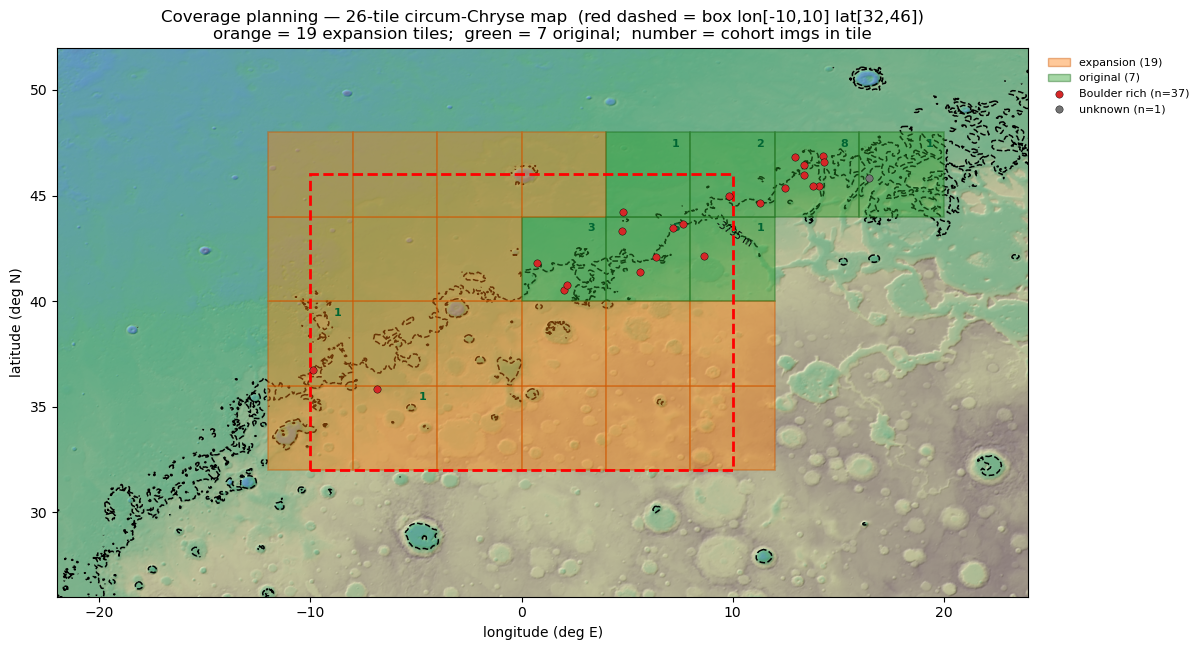

In [4]:
import math, rasterio
from src.validation_retrieve import hillshade

WIDE = REPO / "cache_v2" / "validation" / "mola_dem_wide.tif"
BOX = dict(lonmin=-10.0, lonmax=10.0, latmin=32.0, latmax=46.0)
MAP_TILES = [(lo, la) for lo in range(-12, 12, 4) for la in range(32, 48, 4)] + [(12, 44), (16, 44)]
CURRENT = {(0, 40), (4, 40), (4, 44), (8, 40), (8, 44), (12, 44), (16, 44)}
counts = {(int(np.floor(r.CenterLon_180 / 4) * 4), int(np.floor(r.CenterLat / 4) * 4)): 0
          for _, r in cohort.iterrows()}
for _, r in cohort.iterrows():
    counts[(int(np.floor(r.CenterLon_180 / 4) * 4), int(np.floor(r.CenterLat / 4) * 4))] += 1

if not WIDE.exists():
    print("No wide MOLA basemap yet:", WIDE.relative_to(REPO))
    print("Make it once:  python scripts/fetch_wide_basemap.py  (downloads the 2 GB global MOLA, caches a coarse reprojection)")
else:
    with rasterio.open(WIDE) as ds:
        dem = ds.read(1); T = ds.transform; res_m = abs(T.a)
    R = 3396190.0; dpm = 180.0 / (math.pi * R)
    hh, ww = dem.shape
    we = [T.c * dpm, (T.c + ww * T.a) * dpm, (T.f + hh * T.e) * dpm, T.f * dpm]
    Lo = np.linspace(we[0], we[1], ww); La = np.linspace(we[3], we[2], hh)
    Log, Lag = np.meshgrid(Lo, La)
    hs = hillshade(dem, res_m=res_m, azimuth_deg=315, altitude_deg=45)

    fig, ax = plt.subplots(figsize=(12.5, 6.6))
    ax.imshow(hs, cmap="gray", extent=we, origin="upper", aspect="equal", zorder=0)
    ax.imshow(np.ma.masked_invalid(dem), cmap="terrain", extent=we, origin="upper",
              aspect="equal", alpha=0.38, zorder=1)
    cs = ax.contour(Log, Lag, dem, levels=[-3795], colors="k", linewidths=1.1, zorder=2)
    ax.clabel(cs, fmt={-3795: "-3795 m"}, fontsize=7)
    for (lo, la) in MAP_TILES:
        new = (lo, la) not in CURRENT
        ax.add_patch(Rectangle((lo, la), TILE_DEG, TILE_DEG,
                               facecolor=("#ff7f0e" if new else "#2ca02c"),
                               edgecolor=("#cc5500" if new else "#1a6b1a"),
                               lw=1.2, alpha=0.42, zorder=3))
        n = counts.get((lo, la), 0)
        if n:
            ax.text(lo + 3.3, la + 3.3, f"{n}", ha="center", fontsize=8, fontweight="bold",
                    color="#063", zorder=5)
    ax.add_patch(Rectangle((BOX["lonmin"], BOX["latmin"]), BOX["lonmax"] - BOX["lonmin"],
                           BOX["latmax"] - BOX["latmin"], fill=False, edgecolor="red",
                           lw=2.0, ls="--", zorder=6))
    for lab, c in {"Boulder rich": "#d62728", "unknown": "0.45"}.items():
        sub = cohort[(cohort.BoulderLabel == lab) & cohort.CenterLon_180.between(we[0], we[1])
                     & cohort.CenterLat.between(we[2], we[3])]
        ax.scatter(sub.CenterLon_180, sub.CenterLat, s=28, c=c, edgecolor="k", lw=0.3,
                   zorder=7, label=f"{lab} (n={len(sub)})")
    from matplotlib.patches import Patch
    h2, _ = ax.get_legend_handles_labels()
    ax.legend(handles=[Patch(fc="#ff7f0e", alpha=0.42, ec="#cc5500", label="expansion (19)"),
                       Patch(fc="#2ca02c", alpha=0.42, ec="#1a6b1a", label="original (7)")] + h2,
              loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
    ax.set_xlim(-22, 24); ax.set_ylim(26, 52)
    ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
    ax.set_title("Coverage planning — 26-tile circum-Chryse map  (red dashed = box lon[-10,10] lat[32,46])\n"
                 "orange = 19 expansion tiles;  green = 7 original;  number = cohort imgs in tile")
    fig.tight_layout()
    out = FIG / "24_coverage_planning.png"; fig.savefig(out, dpi=145, bbox_inches="tight")
    print("wrote", out.relative_to(REPO)); plt.show()

## 1b. Regional context — MOLA shaded-relief underlay (PLAN §5 fig 1)

The independent geological frame for the map: **MOLA MEGDM topography** (463 m/px, USGS),
fetched + reprojected onto the CTX `clon_0` CRS by `src/validation_retrieve.py`
(`python scripts/fetch_validation_data.py --product mola_dem`) so it co-registers with the abundance
mosaic. Shaded relief underlay + the paper's paleoshoreline elevations as context contours
(**−3795 m lHl1**, **−4100 m lHl2**; [Rodriguez et al. 2016](https://doi.org/10.1038/srep25106)).
The −3795 m contour separates the bouldery highland–lowland run-up zone (PLAN §1 prediction 1)
from the distal Chryse plains; the boulder-rich cohort sites should cluster on the highland
side of it. *(Sanity: the eastern boundary block's median elevation came back −3794 m — right on
the lHl1 shoreline — and the contour threads through the whole map, with the southern tiles
(lat 32–40) climbing above it into the highlands and the NW lowering toward the lowland plains.)*


wrote reports\figures\24_region_context_mola.png


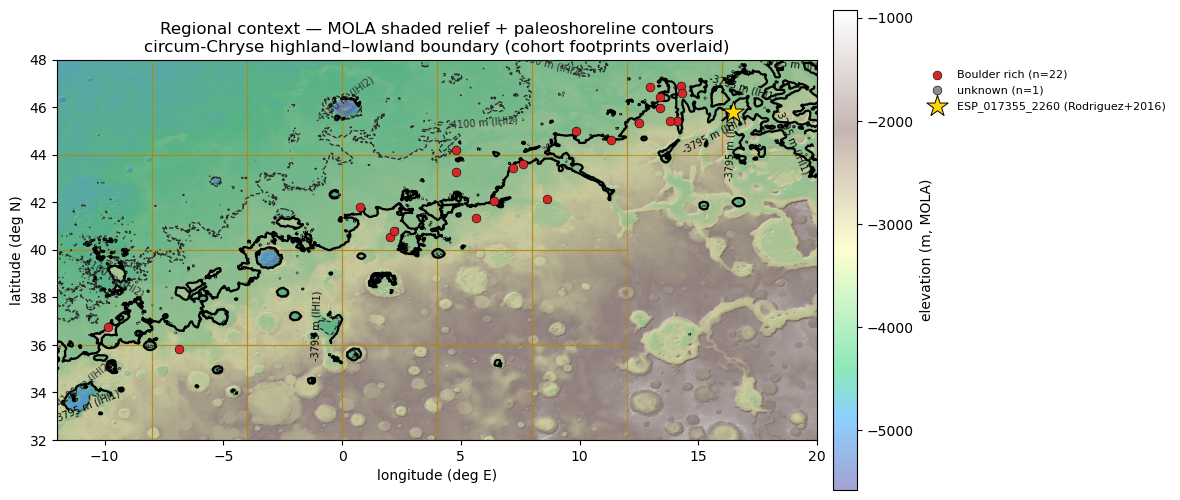

In [5]:
import math
import rasterio
from src.validation_retrieve import hillshade

MOLA = REPO / "cache_v2" / "validation" / "mola_dem_region.tif"
if not MOLA.exists():
    print("No MOLA raster yet:", MOLA.relative_to(REPO))
    print("Fetch it:  python scripts/fetch_validation_data.py --product mola_dem")
else:
    with rasterio.open(MOLA) as ds:
        dem = ds.read(1)
        T = ds.transform
        res_m = abs(T.a)
    R = 3396190.0; dpm = 180.0 / (math.pi * R)           # clon_0 metres -> degrees
    h, w = dem.shape
    lon0, lat1 = T.c * dpm, T.f * dpm                     # top-left
    lon1, lat0 = (T.c + w * T.a) * dpm, (T.f + h * T.e) * dpm
    mext = [lon0, lon1, lat0, lat1]
    lon = np.linspace(lon0, lon1, w); lat = np.linspace(lat1, lat0, h)
    LON, LAT = np.meshgrid(lon, lat)
    hs = hillshade(dem, res_m=res_m, azimuth_deg=315, altitude_deg=45)

    fig, ax = plt.subplots(figsize=(12, 6.0))
    ax.imshow(hs, cmap="gray", extent=mext, origin="upper", aspect="equal", zorder=0)
    im = ax.imshow(np.ma.masked_invalid(dem), cmap="terrain", extent=mext, origin="upper",
                   aspect="equal", alpha=0.45, zorder=1)
    cs = ax.contour(LON, LAT, dem, levels=[-4100, -3795], colors=["#2b2b2b", "k"],
                    linewidths=[0.9, 1.6], linestyles=["--", "-"], zorder=3)
    ax.clabel(cs, fmt={-4100: "-4100 m (lHl2)", -3795: "-3795 m (lHl1)"}, fontsize=7)
    for t, (lo, la) in boxes.items():                    # the 7 inference tiles
        ax.add_patch(Rectangle((lo, la), TILE_DEG, TILE_DEG, fill=False,
                               edgecolor="#b8860b", lw=0.8, alpha=0.7, zorder=2))
    for lab, c in COL.items():                           # cohort footprints
        sub = in_block[in_block.BoulderLabel == lab]
        if len(sub):
            ax.scatter(sub.CenterLon_180, sub.CenterLat, s=40, c=c, edgecolor="k", lw=0.4,
                       label=f"{lab} (n={len(sub)})", zorder=5)
    pi = cohort[cohort.ObsId == PAPER_IMG]
    if len(pi):
        ax.scatter(pi.CenterLon_180, pi.CenterLat, s=260, marker="*", facecolor="gold",
                   edgecolor="k", lw=0.7, zorder=6, label=f"{PAPER_IMG} (Rodriguez+2016)")
    ax.set_xlim(mext[0], mext[1]); ax.set_ylim(mext[2], mext[3])
    ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
    ax.set_title("Regional context — MOLA shaded relief + paleoshoreline contours\n"
                 "circum-Chryse highland–lowland boundary (cohort footprints overlaid)")
    fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02, label="elevation (m, MOLA)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.13, 1.0), fontsize=8, frameon=False)
    fig.tight_layout()
    out = FIG / "24_region_context_mola.png"; fig.savefig(out, dpi=150, bbox_inches="tight")
    print("wrote", out.relative_to(REPO)); plt.show()

## 2. Stitched regional abundance mosaic

`scripts/map_region.py --all` writes per Murray tile `<tile>_{prob,abundance,prob_raw}.tif`
(160 m/px) to `reports/map_region/`. All 26 share the Murray `clon_0` equirectangular CRS, so
`src.mapping.mosaic_geotiffs` merges them into **one** georeferenced raster — no reprojection;
the map is the lon[-12,12] box plus a NE tab (`E12/E16_N44`), so the SE corner of the bounding
rectangle (lon 12–20, lat 32–44) is nodata. Below is the calibrated `fractional_area` abundance
with the cohort footprints overlaid: high-abundance terrain should track the boulder-rich cohort
sites along the highland–lowland boundary (the qualitative form of validation leg 4, ahead of
the quantitative legs in §3).


wrote reports\figures\24_region_mosaic.png + reports\map_region\regional_abundance_mosaic.tif


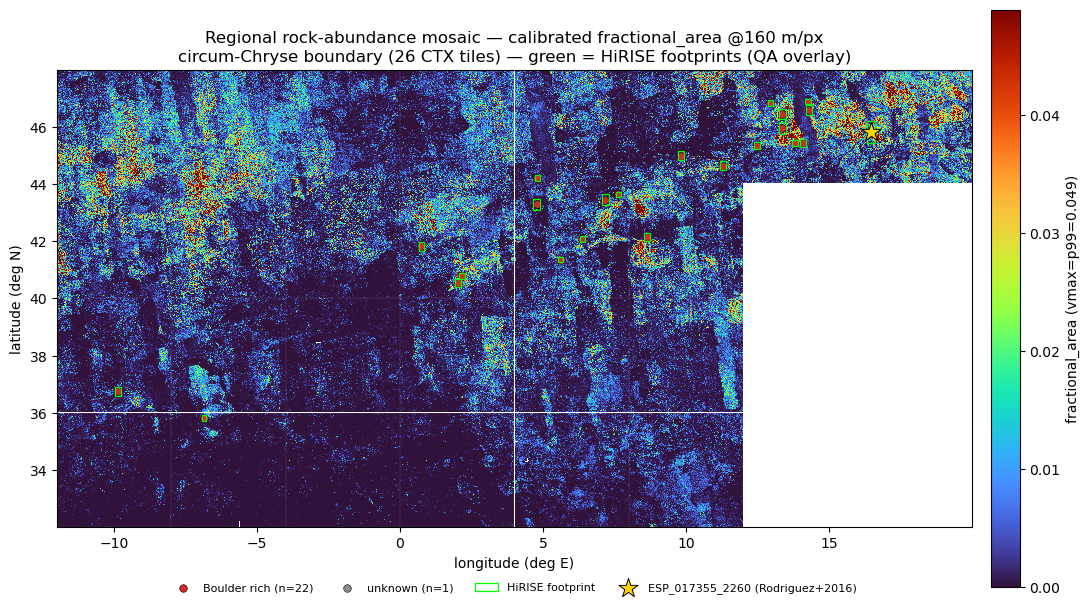

In [6]:
import math
from src.mapping import mosaic_geotiffs
MAP_DIR = REPO / "reports" / "map_region"
ab_tifs = sorted(MAP_DIR.glob("*_abundance.tif")) if MAP_DIR.exists() else []
if not ab_tifs:
    print("No abundance GeoTIFFs yet under reports/map_region/.")
    print("Run on Sherlock:  python scripts/map_region.py --all  -> download *.tif into reports/map_region/.")
else:
    arr, transform, _ = mosaic_geotiffs(ab_tifs, MAP_DIR / "regional_abundance_mosaic.tif")
    R = 3396190.0; dpm = 180.0 / (math.pi * R)   # clon_0 equirectangular metres -> degrees
    h, w = arr.shape
    left, top = transform.c, transform.f
    right, bottom = left + w * transform.a, top + h * transform.e
    ext = [left * dpm, right * dpm, bottom * dpm, top * dpm]   # lon0, lon1, lat0, lat1
    vmax = float(np.nanpercentile(arr, 99)) or 1e-3

    fig, ax = plt.subplots(figsize=(11, 6.6))
    im = ax.imshow(np.ma.masked_invalid(arr), cmap="turbo", vmin=0, vmax=vmax, extent=ext,
                   origin="upper", interpolation="nearest", aspect="equal")
    for t, (lo, la) in boxes.items():                      # tile outlines
        ax.add_patch(Rectangle((lo, la), TILE_DEG, TILE_DEG, fill=False,
                               edgecolor="white", lw=0.3, alpha=0.12))  # faint: the grid is not data
    for lab, c in COL.items():                             # cohort centres (label colour)
        sub = in_block[in_block.BoulderLabel == lab]
        if len(sub):
            ax.scatter(sub.CenterLon_180, sub.CenterLat, s=30, c=c, edgecolor="k", lw=0.4,
                       label=f"{lab} (n={len(sub)})", zorder=4)
    # HiRISE footprint outlines (real Stage-2 window bounds) — QA: abundance structure must NOT
    # trace these boxes (the map is off-HiRISE CTX inference; HiRISE never enters it).
    fp_drawn = 0
    for oid, (flo0, fla0, flo1, fla1) in footprints.items():
        if flo1 < ext[0] or flo0 > ext[1] or fla1 < ext[2] or fla0 > ext[3]:
            continue
        ax.add_patch(Rectangle((flo0, fla0), flo1 - flo0, fla1 - fla0, fill=False,
                               edgecolor="lime", lw=0.9, zorder=6,
                               label="HiRISE footprint" if fp_drawn == 0 else None))
        fp_drawn += 1
    pi = cohort[cohort.ObsId == PAPER_IMG]
    if len(pi):
        ax.scatter(pi.CenterLon_180, pi.CenterLat, s=210, marker="*", facecolor="gold",
                   edgecolor="k", lw=0.7, zorder=7, label=f"{PAPER_IMG} (Rodriguez+2016)")
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
    ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
    ax.set_title("Regional rock-abundance mosaic — calibrated fractional_area @160 m/px\n"
                 "circum-Chryse boundary (26 CTX tiles) — green = HiRISE footprints (QA overlay)")
    fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02, label=f"fractional_area (vmax=p99={vmax:.3f})")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=8, frameon=False)
    fig.tight_layout()
    out = FIG / "24_region_mosaic.png"; fig.savefig(out, dpi=150, bbox_inches="tight")
    print("wrote", out.relative_to(REPO), "+", (MAP_DIR / "regional_abundance_mosaic.tif").relative_to(REPO))
    plt.show()

### 2b. All three products side by side

The same stitch applied to the **calibrated P(boulder-rich)** tiles, plus the **binary
rich/poor** map (threshold P ≥ 0.5). Abundance (continuous regression target) and
probability (the classifier) carry the same spatial structure; the binary panel is what a
"where are the boulder fields" map looks like. Boulder-rich cohort sites in cyan.


wrote reports\figures\24_region_products.png


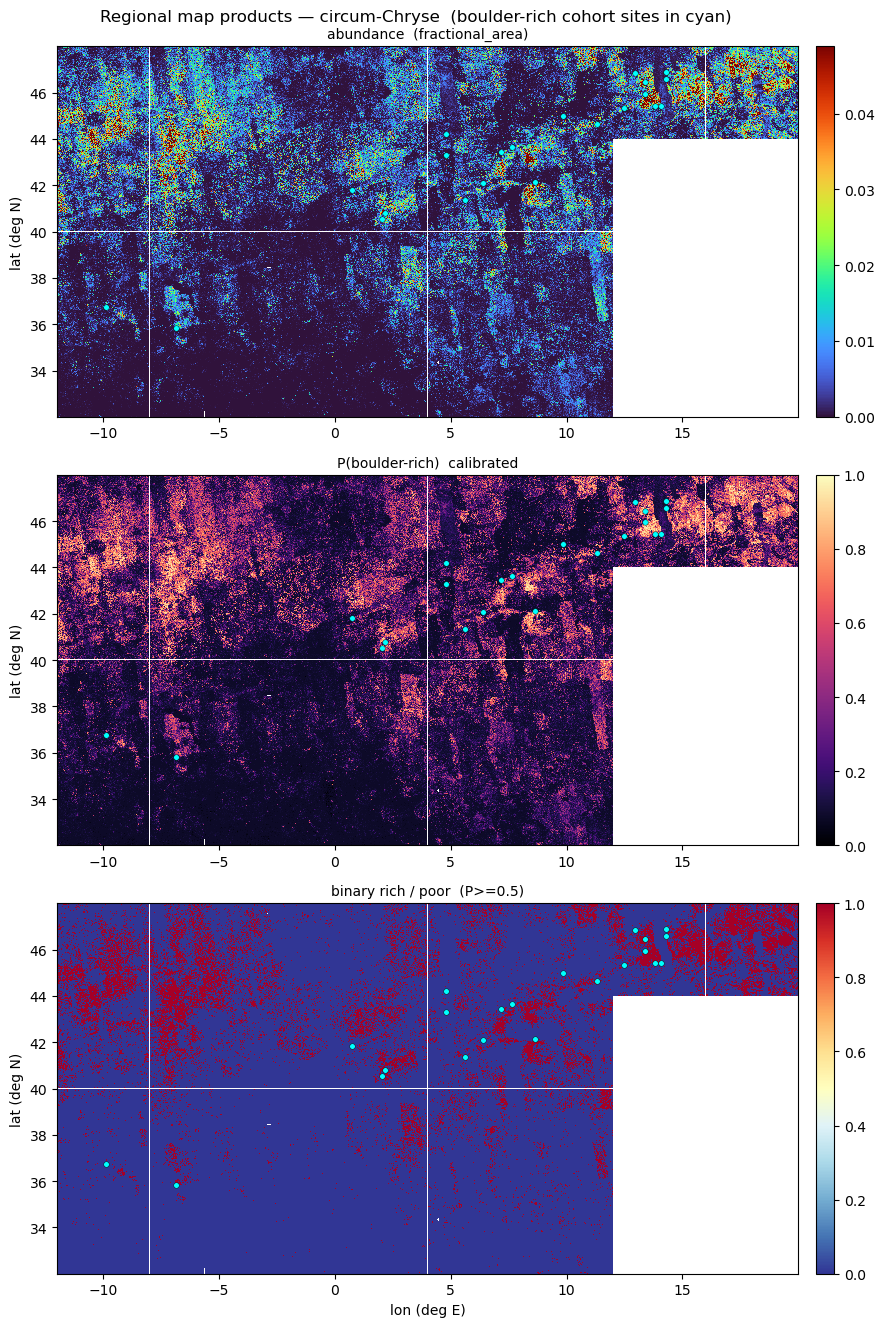

In [7]:
if ab_tifs:
    prob_arr, _, _ = mosaic_geotiffs(sorted(MAP_DIR.glob("*_prob.tif")),
                                     MAP_DIR / "regional_prob_mosaic.tif")
    binary = np.where(np.isfinite(prob_arr), (prob_arr >= 0.5).astype(float), np.nan)
    rich = in_block[in_block.BoulderLabel == "Boulder rich"]

    panels = [("abundance  (fractional_area)", arr,      "turbo",    0.0, vmax),
              ("P(boulder-rich)  calibrated", prob_arr,  "magma",    0.0, 1.0),
              ("binary rich / poor  (P>=0.5)", binary,   "RdYlBu_r", 0.0, 1.0)]
    fig, axes = plt.subplots(3, 1, figsize=(9.5, 13.5))   # vertical stack (region is wide)
    for ax, (title, data, cmap, vmin, vmx) in zip(axes, panels):
        im = ax.imshow(np.ma.masked_invalid(data), cmap=cmap, vmin=vmin, vmax=vmx, extent=ext,
                       origin="upper", aspect="equal", interpolation="nearest")
        ax.scatter(rich.CenterLon_180, rich.CenterLat, s=16, c="cyan", edgecolor="k",
                   lw=0.3, zorder=4)
        ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
        ax.set_title(title, fontsize=10); ax.set_ylabel("lat (deg N)")
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    axes[-1].set_xlabel("lon (deg E)")
    fig.suptitle("Regional map products — circum-Chryse  (boulder-rich cohort sites in cyan)",
                 fontsize=12)
    fig.tight_layout()
    out = FIG / "24_region_products.png"; fig.savefig(out, dpi=145, bbox_inches="tight")
    print("wrote", out.relative_to(REPO)); plt.show()

### 2c. Binary boulder map on the MOLA terrain (where are the boulder fields?)

The deliverable read of the map: predicted **boulder-rich (P ≥ 0.5)** tiles overlaid in red on
the MOLA shaded-relief background, predicted-poor dimmed, with the **−3795 m lHl1 paleoshoreline**
and the cohort boulder-rich truth sites (yellow triangles). This is the qualitative form of
PLAN legs 1/3/4 in one frame: the predicted boulder fields should hug the highland side of the
contour (the run-up zone) and coincide with the cohort truth, while the distal lowland plains
stay poor. Co-registration is exact — both layers are in the CTX `clon_0` CRS.


wrote reports\figures\24_region_binary_on_mola.png


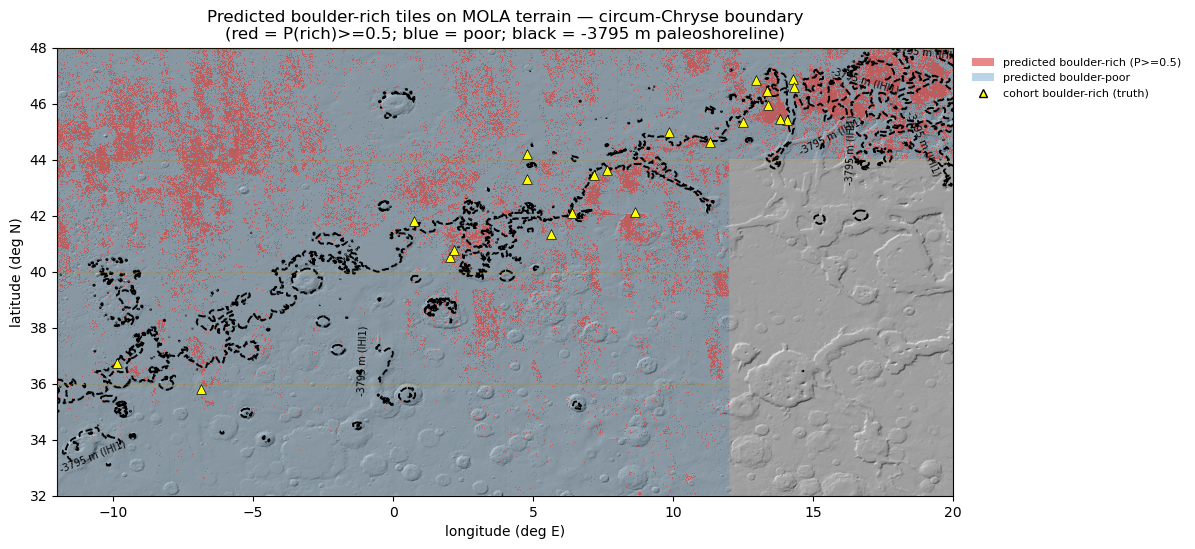

In [8]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
if ab_tifs and MOLA.exists():
    rich_overlay = np.where(binary == 1, 1.0, np.nan)   # predicted boulder-rich
    poor_overlay = np.where(binary == 0, 1.0, np.nan)   # predicted boulder-poor

    fig, ax = plt.subplots(figsize=(12, 6.0))
    ax.imshow(hs, cmap="gray", extent=mext, origin="upper", aspect="equal", zorder=0)
    ax.imshow(np.ma.masked_invalid(poor_overlay), cmap=ListedColormap(["#1f77b4"]), extent=ext,
              origin="upper", aspect="equal", alpha=0.18, zorder=1, interpolation="nearest")
    ax.imshow(np.ma.masked_invalid(rich_overlay), cmap=ListedColormap(["#d62728"]), extent=ext,
              origin="upper", aspect="equal", alpha=0.55, zorder=2, interpolation="nearest")
    cs = ax.contour(LON, LAT, dem, levels=[-3795], colors="k", linewidths=1.4, zorder=3)
    ax.clabel(cs, fmt={-3795: "-3795 m (lHl1)"}, fontsize=7)
    for t, (lo, la) in boxes.items():
        ax.add_patch(Rectangle((lo, la), TILE_DEG, TILE_DEG, fill=False, edgecolor="#b8860b",
                               lw=0.4, alpha=0.22, zorder=4))
    ax.scatter(rich.CenterLon_180, rich.CenterLat, s=48, marker="^", facecolor="yellow",
               edgecolor="k", lw=0.5, zorder=6)

    ax.set_xlim(mext[0], mext[1]); ax.set_ylim(mext[2], mext[3])
    ax.set_xlabel("longitude (deg E)"); ax.set_ylabel("latitude (deg N)")
    ax.set_title("Predicted boulder-rich tiles on MOLA terrain — circum-Chryse boundary\n"
                 "(red = P(rich)>=0.5; blue = poor; black = -3795 m paleoshoreline)")
    handles = [Patch(facecolor="#d62728", alpha=0.55, label="predicted boulder-rich (P>=0.5)"),
               Patch(facecolor="#1f77b4", alpha=0.30, label="predicted boulder-poor"),
               plt.Line2D([], [], marker="^", ls="", mfc="yellow", mec="k",
                          label="cohort boulder-rich (truth)")]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8,
              frameon=False)
    fig.tight_layout()
    out = FIG / "24_region_binary_on_mola.png"; fig.savefig(out, dpi=150, bbox_inches="tight")
    print("wrote", out.relative_to(REPO)); plt.show()

## 3. Validation legs *(to come — PLAN §2)*

1. **Spatial co-location** — abundance band ↔ THEMIS thermal-bright ↔ mapped contact.
2. **Thermal-inertia correlation** — rank-corr(abundance, TES TI), dust-masked.
3. **Shoreline-distance profile** — abundance vs distance from the −3795 m MOLA contour.
4. **Truth anchor** — predictions vs BoulderNet detections at `ESP_017355_2260`.
5. **Generalisation** — does the band continue along un-imaged boundary segments?

These require `src/validation_retrieve.py` (PLAN phase 1) and the returned GeoTIFFs; they
land here as they are built.
